In [1]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
from utils.logger import get_logger
_logs = get_logger(__name__)

In [2]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import os
from glob import glob

In [3]:
ft_dir = os.getenv("FEATURES_DATA")
ft_glob = glob(os.path.join(ft_dir, '**/*.parquet'), 
               recursive = True)
df = dd.read_parquet(ft_glob).compute().reset_index()

In [ ]:
type(df) # computed version of dask data frameis panda dataframe

pandas.core.frame.DataFrame

# Sampling in Python

+ There are different packages that allow sampling.
+ A practical approach is to use pandas/Dask sampling methods.

## Random Sampling

+ Sample n rows from a dataframe with [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html).

```
DataFrame.sample(
    n=None, frac=None, replace=False, weights=None, 
    random_state=None, axis=None, ignore_index=False
    )
```

In [ ]:
df.sample(n = 5)# 5 observations

,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1
28810,BWG,2018-03-28,12.810000,12.830000,12.740000,12.830000,11.113527,16800.0,BWG.csv,2018,12.770000
71771,GAZ,2014-09-26,2.490000,2.510000,2.480000,2.510000,2.510000,9400.0,GAZ.csv,2014,2.490000
153135,REG,2004-12-16,53.849998,53.939999,53.080002,53.200001,28.856192,216700.0,REG.csv,2004,53.700001
153996,REG,2008-05-20,68.790001,68.910004,67.709999,67.870003,42.172504,420800.0,REG.csv,2008,68.959999
203425,TNC,1998-04-24,21.562500,21.562500,21.453125,21.453125,12.180079,1800.0,TNC.csv,1998,21.468750


In [ ]:
import random
random.seed(42)
sample_tickers = random.sample(df['ticker'].unique().tolist(), 30)
df = df[df['ticker'].isin(sample_tickers)]
simple_sample_dt = df.sample(frac = 0.1)# 10% of observations
simple_sample_dt.shape, df.shape

((10334, 11), (103335, 11))

Look at the distribution of tickers.

<Axes: xlabel='ticker'>

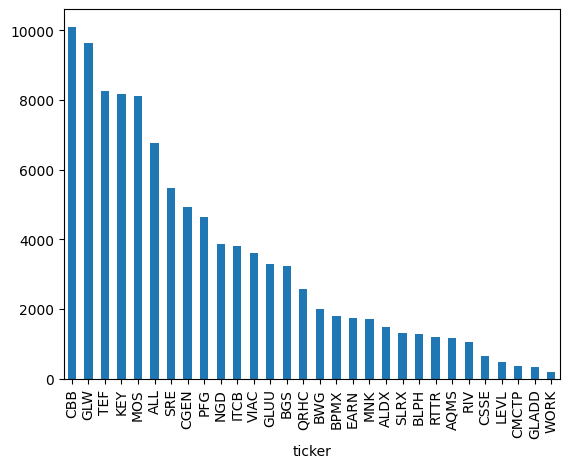

In [ ]:
# df['ticker'].value_counts() gives a data series, you cn check with type
df['ticker'].value_counts().plot(kind='bar')

<Axes: xlabel='ticker'>

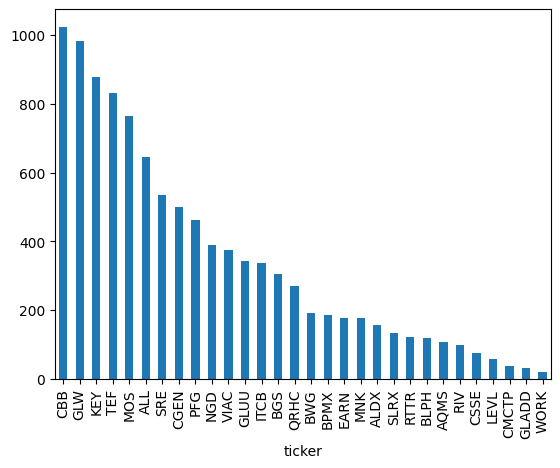

In [7]:
simple_sample_dt['ticker'].value_counts().plot(kind='bar')

## Stratified Sampling

+ Use `groupby()` and `.sample()` for stratified sampling.

<Axes: xlabel='ticker'>

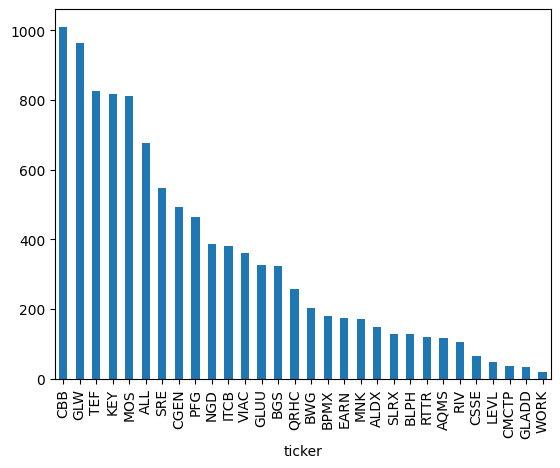

In [ ]:
strat_sample_dt = df.groupby(['ticker']).sample(frac = 0.1)# on each group we take 10% of the group
strat_sample_dt['ticker'].value_counts().plot(kind='bar') # store in ra_s.. and plot it

# Sampling in Dask

+ Stratified sampling in `dask` can be achieved with `groupby().apply()` and a lambda function.

C:\Users\cheki\AppData\Local\Temp\ipykernel_15172\1783207470.py:2: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  strat_sample_dd = (dd_dt


<Axes: xlabel='ticker'>

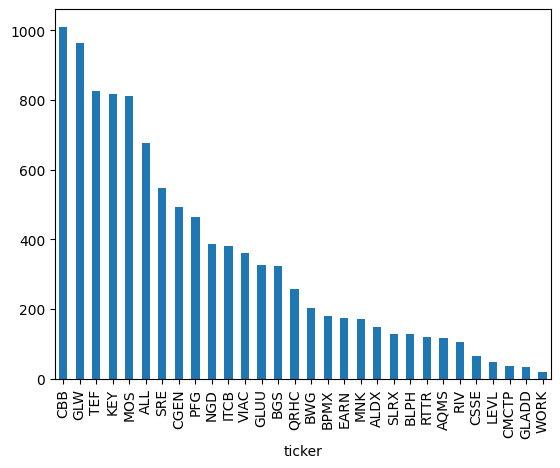

In [ ]:
dd_dt = dd.read_parquet(ft_glob) # lump everything as much as we can, load data, prompt, group it, apply a function which is sampleing of 10%, compute it , rest the index, then plotting 
strat_sample_dd = (dd_dt
                      .groupby('ticker', group_keys=False)
                      .apply(lambda x: x.sample(frac = 0.1))
                      .compute()
                      .reset_index())
strat_sample_dd[strat_sample_dd['ticker'].isin(sample_tickers)]['ticker'].value_counts().plot(kind='bar')